# 02 - 用地布局生成

**目标**：在 haidian 边界内生成模拟的用地分区（无间隙、无重叠）。

**算法**：
1. 将边界矩形网格化细分（grid subdivision）
2. 按目标用地比例随机分配 land_use_code
3. 用 `shapely.ops.unary_union` 验证覆盖性

**学习要点**：
- 空间分区算法基础
- 用地比例约束下的随机分配
- 用拓扑操作验证生成结果

In [1]:
import sys
sys.path.insert(0, '..')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.ops import unary_union, transform
from shapely.geometry import Polygon
import pyproj

from src.projection import transform_geometry, CRS_4326, CRS_4548
from src.generation import (
    subdivide_boundary,
    assign_land_use,
    LAND_USE_COLORS,
    LAND_USE_LABELS,
)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load boundary and transform to EPSG:4548
gdf_all = gpd.read_file('../data/haidian-boundary.geojson')
site = gdf_all[gdf_all['id'] == 'PROV-SITE-001'].iloc[0]

boundary_4548 = transform_geometry(site.geometry, CRS_4326, CRS_4548)

print(f'Boundary: {site["name_zh"]}')
print(f'Area (EPSG:4548): {boundary_4548.area:,.0f} sqm = {boundary_4548.area/1e6:.4f} km²')
print(f'Bounds: ({boundary_4548.bounds[0]:.0f}, {boundary_4548.bounds[1]:.0f}) → ({boundary_4548.bounds[2]:.0f}, {boundary_4548.bounds[3]:.0f}) metres')

Boundary: 总体设计范围粗略替代边界
Area (EPSG:4548): 11,412,825 sqm = 11.4128 km²
Bounds: (443594, 4422955) → (444968, 4432678) metres


## Step 1: 网格细分

将边界多边形划分为 20x15 的网格（共 300 个潜在单元），裁剪到边界内。

**实现要点**：`subdivide_boundary` 使用单次平面布线（planar noding）——把边界环与所有网格线合并后一次性 `unary_union` + `polygonize`。这样相邻地块共享完全相同的边坐标，从根本上避免独立裁剪产生的浮点狭缝（slivers）、微小间隙和边界溢出，保证生成结果严格满足"无间隙、无重叠、完全包含"。

In [3]:
N_ROWS = 20
N_COLS = 15

cells = subdivide_boundary(boundary_4548, N_ROWS, N_COLS)
print(f'Grid: {N_ROWS}x{N_COLS} = {N_ROWS*N_COLS} potential cells')
print(f'Cells within boundary: {len(cells)}')
print(f'Cell geometry types: {set(c.geom_type for c in cells)}')

Grid: 20x15 = 300 potential cells
Cells within boundary: 278
Cell geometry types: {'Polygon'}


## Step 2: 分配用地类型

按目标比例随机分配。用地代码遵循 GB 50137-2011（城市用地分类与规划建设用地标准）：教育科研（A3）属于 A 公共管理与公共服务用地；E 为非建设用地（不用于建设用地地块），因此默认混合不包含 E。

| 代码 | 类型 | 目标比例 |
|------|------|---------|
| R | 居住用地 | 35% |
| A | 公共管理与公共服务（含教育 A3） | 18% |
| B | 商业服务业设施 | 12% |
| G | 绿地与广场 | 20% |
| S | 道路与交通设施 | 15% |

In [4]:
land_use_gdf = assign_land_use(cells, random_seed=42)

print(f'Parcels generated: {len(land_use_gdf)}')
print(f'CRS: {land_use_gdf.crs}')
print()

# Show distribution
print('Land use distribution:')
print(land_use_gdf['land_use_code'].value_counts())
print()

# Area by type
land_use_gdf['area_sqm'] = land_use_gdf.geometry.area
total_area = land_use_gdf['area_sqm'].sum()
print(f'Total parcel area: {total_area:,.0f} sqm')
print()
for code in sorted(land_use_gdf['land_use_code'].unique()):
    subset = land_use_gdf[land_use_gdf['land_use_code'] == code]
    area = subset['area_sqm'].sum()
    pct = area / total_area * 100
    label = LAND_USE_LABELS.get(code, code)
    print(f'  {label:30s} {area:12,.0f} sqm ({pct:5.1f}%)')

Parcels generated: 278
CRS: EPSG:4548

Land use distribution:
land_use_code
R    106
S     49
G     43
B     40
A     40
Name: count, dtype: int64

Total parcel area: 11,412,825 sqm

  A 公共管理与公共服务用地                     1,657,680 sqm ( 14.5%)
  B 商业服务业设施用地                       1,509,571 sqm ( 13.2%)
  G 绿地与广场用地                         1,714,078 sqm ( 15.0%)
  R 居住用地                            4,414,361 sqm ( 38.7%)
  S 道路与交通设施用地                       2,117,135 sqm ( 18.6%)


## Step 3: 验证 — 无间隙、无重叠

由于 subdivision 走单次 noding，地块之间共享完全相同的边，重叠检查应严格为 0。覆盖检查以面积差判断（`boundary - union` 的面积 < 容差即视为无间隙）——这比坐标精确的 `covers()` 谓词稳健：`covers()` 会在最后一位浮点上误报失败，即使真实面积差为 0。

In [5]:
# Coverage check (area-based: gap < tolerance counts as fully covered)
from src.topology import check_coverage, AREA_TOLERANCE_SQM

covered, gaps = check_coverage(land_use_gdf, boundary_4548)

print('=== Coverage Check ===')
print(f'Parcel count: {len(land_use_gdf)}')
print(f'Total parcel area: {land_use_gdf.geometry.area.sum():,.2f} sqm')
print(f'Boundary area: {boundary_4548.area:,.2f} sqm')
print(f'Coverage passed (gap <= {AREA_TOLERANCE_SQM} m²): {covered}')
print(f'Gaps found: {len(gaps)}')
print(f'Gap area: {boundary_4548.difference(unary_union(land_use_gdf.geometry.values)).area:.6f} sqm')
print(f'Gap as % of boundary: {boundary_4548.difference(unary_union(land_use_gdf.geometry.values)).area/boundary_4548.area*100:.8f}%')

=== Coverage Check ===
Parcel count: 278
Total parcel area: 11,412,825.39 sqm
Boundary area: 11,412,825.39 sqm
Coverage passed (gap <= 0.0001 m²): True
Gaps found: 0
Gap area: 0.000000 sqm
Gap as % of boundary: 0.00000000%


In [6]:
# Overlap check
from src.topology import check_overlaps

clean, overlaps = check_overlaps(land_use_gdf)
print(f'=== Overlap Check ===')
print(f'No overlaps: {clean}')
print(f'Overlap regions found: {len(overlaps)}')

if overlaps:
    total_overlap_area = sum(o.area for o in overlaps)
    print(f'Total overlap area: {total_overlap_area:,.2f} sqm')
else:
    print('✓ All parcels are non-overlapping')

=== Overlap Check ===
No overlaps: True
Overlap regions found: 0
✓ All parcels are non-overlapping


## Step 4: 可视化

用专业规划色系绘制用地布局图。

/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_84382/4174342066.py:21: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_84382/4174342066.py:21: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_84382/4174342066.py:21: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_84382/4174342066.py:21: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_84382/4174342066.py:21: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2

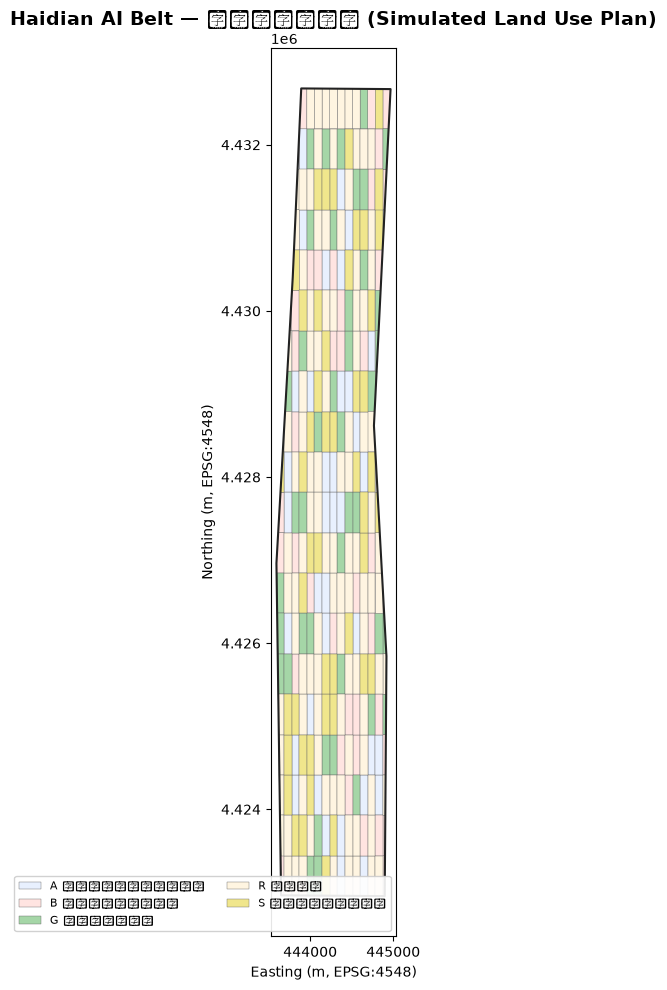

In [7]:
fig, ax = plt.subplots(figsize=(14, 10))

# Plot each land use category
codes_present = sorted(land_use_gdf['land_use_code'].unique())
for code in codes_present:
    subset = land_use_gdf[land_use_gdf['land_use_code'] == code]
    color = LAND_USE_COLORS.get(code, '#CCCCCC')
    label = LAND_USE_LABELS.get(code, code)
    subset.plot(ax=ax, color=color, edgecolor='#666666', linewidth=0.3, label=label)

# Boundary outline
gpd.GeoSeries([boundary_4548]).plot(
    ax=ax, facecolor='none', edgecolor='#222222', linewidth=1.5
)

ax.set_title('Haidian AI Belt — 模拟用地布局图 (Simulated Land Use Plan)', fontsize=14, fontweight='bold')
ax.set_xlabel('Easting (m, EPSG:4548)')
ax.set_ylabel('Northing (m, EPSG:4548)')
ax.legend(loc='lower right', fontsize=8, framealpha=0.9, ncol=2)

plt.tight_layout()
plt.savefig('../outputs/land_use_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 总结

- 成功在 haidian 边界内生成了无间隙、无重叠的模拟用地分区
- 单次平面布线（planar noding）细分保证了地块共享精确边坐标，从根本上消除浮点狭缝与溢出
- 覆盖性（面积差法）、重叠性（逐对 intersection）、包含性（逐地块差面积）全部通过
- 用地代码遵循 GB 50137-2011：教育并入 A 公共管理与公共服务用地，E 非建设用地不用于建设用地地块
- 下一步：在每个用地分区内生成建筑基底